## Problem 2

In [111]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

### Part 1

In [112]:
def cross_matrix(vec):
    return np.array([[0, -vec[2], vec[1]],
                      [vec[2], 0, -vec[0]],
                      [-vec[1], vec[0], 0]])

### Part 2

In [113]:
def uncross_matrix(mat):
    return np.array([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])


### Part 3

In [114]:
def omega_dot(t, omega, I_B):
    skew_omega= cross_matrix(omega)
    return -np.linalg.inv(I_B) @ (skew_omega @ I_B @ omega)

### Part 4

In [115]:
omega1 = np.array([.9,.1,0])
omega2 = np.array([0.1,0.9,0])

I_B = np.array([[10, 0, 0],
                [0,  5, 0],
                [0,  0, 1]], dtype=float)


time = np.linspace(0,10,1000)
sol1 = solve_ivp(lambda t, y: omega_dot(t,y,I_B),   
                [0,10], omega1,
                t_eval=time,
                atol=1e-8, rtol=1e-8)
sol2 = solve_ivp(lambda t, y: omega_dot(t,y,I_B),   
                [0,10], omega2,
                t_eval=time,
                atol=1e-8, rtol=1e-8)
omegadot_sol1 = sol1.y
omegadot_sol2 = sol2.y


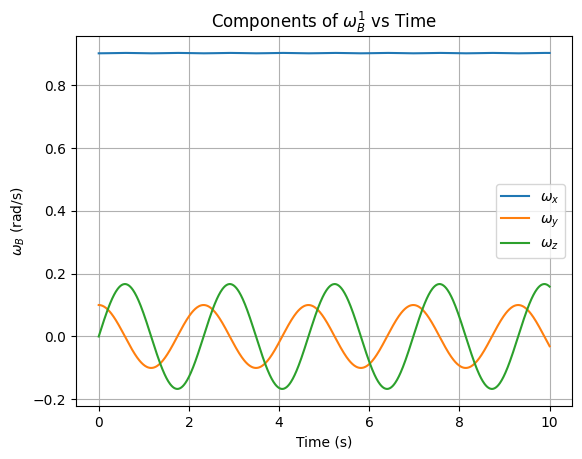

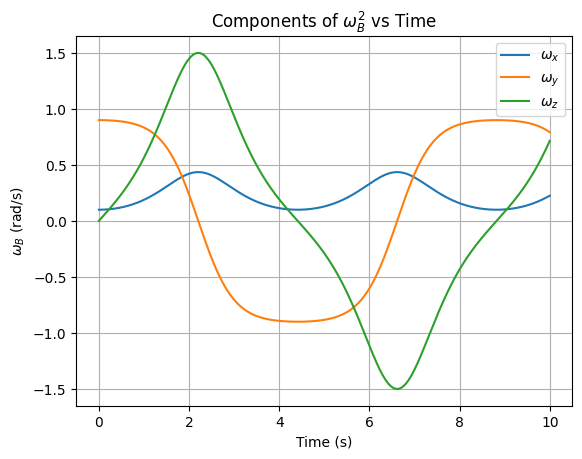

In [116]:
# --- Plot 1: omega1 components vs time ---
plt.figure(1)
plt.clf()
plt.plot(sol1.t, omegadot_sol1[0,:], label=r'$\omega_x$')
plt.plot(sol1.t, omegadot_sol1[1,:], label=r'$\omega_y$')
plt.plot(sol1.t, omegadot_sol1[2,:], label=r'$\omega_z$')
plt.xlabel('Time (s)')
plt.ylabel(r'$\omega_B$ (rad/s)')
plt.title(r'Components of $\omega_B^{1}$ vs Time')
plt.legend()
plt.grid(True)
plt.show()
# --- Plot 2: omega2 components vs time ---
plt.figure(2)
plt.clf()
plt.plot(sol2.t, omegadot_sol2[0,:], label=r'$\omega_x$')
plt.plot(sol2.t, omegadot_sol2[1,:], label=r'$\omega_y$')
plt.plot(sol2.t, omegadot_sol2[2,:], label=r'$\omega_z$')
plt.xlabel('Time (s)')
plt.ylabel(r'$\omega_B$ (rad/s)')
plt.title(r'Components of $\omega_B^{2}$ vs Time')
plt.legend()
plt.grid(True)
plt.show()


### Part 5

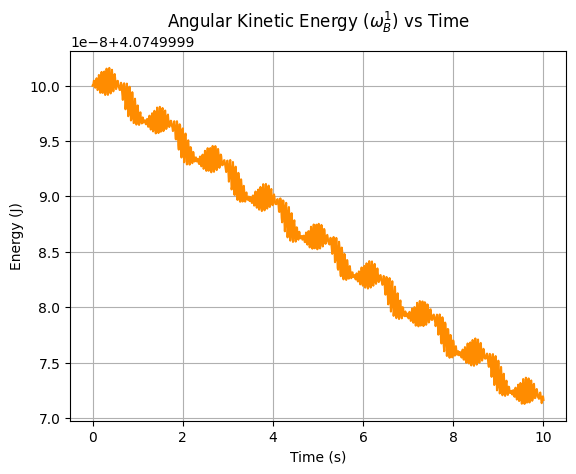

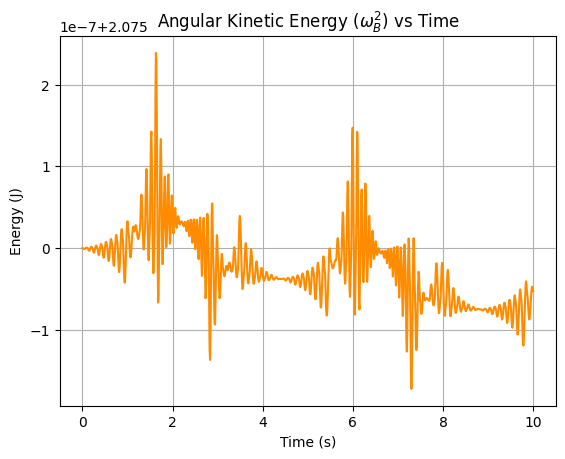

In [117]:
# Plot 2: Angular kinetic energy vs time 
T1 = 0.5 * np.einsum('ij,jk,ki->i', omegadot_sol1.T, I_B, omegadot_sol1)

plt.figure(1)
plt.clf()
plt.plot(sol2.t, T1, color='darkorange')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Angular Kinetic Energy ($\omega_B^{1}$) vs Time')
plt.grid(True)
plt.show()

T2 = 0.5 * np.einsum('ij,jk,ki->i', omegadot_sol2.T, I_B, omegadot_sol2)

plt.figure(1)
plt.clf()
plt.plot(sol2.t, T2, color='darkorange')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Angular Kinetic Energy ($\omega_B^{2})$ vs Time')
plt.grid(True)
plt.show()

## Problem 2

In [118]:
# Problem 3 Euler-Lagrange Simulation
import sympy as sp
from sympy import symbols, pprint, Function, simplify, Derivative, nsimplify
from sympy import sin, cos, asin, acos, pi, diff
from sympy import Matrix, latex, BlockMatrix, lambdify
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import init_printing
init_printing() 

# Define Symbols
t  = symbols("t",   real=True)
m1 = symbols("m1",  positive=True)   # mass of each body-link end mass
m2 = symbols("m2",  positive=True)   # mass at tip of extendable leg
w  = symbols("w",   positive=True)   # half-width of body link
g  = symbols("g",   positive=True)   # gravitational acceleration
omega = symbols("omega", positive=True)  # forcing frequency

# Config Variables
x = Function('x', real=True)(t)
y = Function('y', real=True)(t)
theta= Function('theta', real=True)(t)
phi= Function('phi', real=True)(t)
theta_dot= Function('theta_dot', real=True)(t)
phi_dot= Function('phi_dot', real=True)(t)
l = Function('l', real=True)(t)

# Defining Various Helper Functions
def cross_matrix(vec):
    return Matrix([[0, -vec[2,0], vec[1,0]],
                      [vec[2,0], 0, -vec[0,0]],
                      [-vec[1,0], vec[0,0], 0]])

def uncross_matrix(mat):
    return Matrix([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

def twist2vec(twist):
    m = Matrix.zeros(6,1)
    m[0:3,0] = uncross_matrix(twist[0:3,0:3])
    m[3:,0] = twist[0:3,3]
    return(m)
    
def R_z(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta), -sin(theta), 0], 
                   [sin(theta), cos(theta), 0],
                   [0, 0, 1]])

def R_y(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[cos(theta),0, sin(theta)], 
                   [0, 1, 0],
                   [-sin(theta), 0, cos(theta)]])

def R_x(theta):
    """
    Function to return an arbitrary transformation matrix 
    This is for sympy symbolic calculation
    """
    return Matrix([[1, 0, 0],
                   [0, cos(theta), -sin(theta)], 
                   [0, sin(theta), cos(theta)]])
    
def T(R, p):
    m = Matrix.zeros(4,4)
    m[0:3, 0:3] = R
    m[:3, 3] = p
    m[3, 3] = 1
    return m


### Part 1 Pose and Shape Variables

The pose variables are:


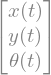

In [119]:
print(f"The pose variables are:")
p=Matrix([x,y,theta])
p

The shape variables are:


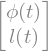

In [120]:
print(f"The shape variables are:")
s=Matrix([phi,l])
s

In [121]:
# T_world_to_body: translate to (x,y), rotate by theta
T1 = T(Matrix.eye(3), Matrix([[x],[y],[0]])) @ T(R_z(theta), Matrix([[0],[0],[0]])) #Trasnfrom to center joint
T1 = simplify(T1)

# T Matrix to Right and Left Masses
T1_right = T1 @ T(Matrix.eye(3,3), Matrix([[w],[0],[0]]))
T1_right = simplify(T1_right)
T1_left  = T1 @ T(Matrix.eye(3,3), Matrix([[-w],[0],[0]]))
T1_left = simplify(T1_left)

# T_body_to_leg: no translation (leg attaches at same joint), rotate by phi
T2 = T1 @ T(R_z(phi), Matrix([[0],[0],[0]])) @ T(Matrix.eye(3,3), Matrix([[0],[-l],[0]]))
T2 = simplify(T2)

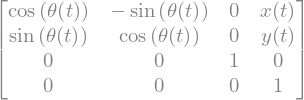

In [122]:
T1

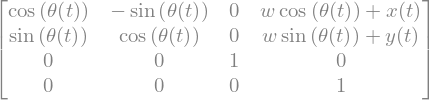

In [123]:
T1_right

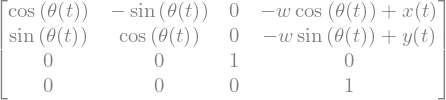

In [124]:
T1_left

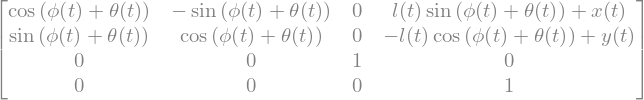

In [125]:
T2

In [126]:
bodytwist_r = simplify(T1_right.inv() @ diff(T1_right, t))  # for right m1
bodytwist_l = simplify(T1_left.inv() @ diff(T1_left, t))  # for left m1
bodytwist_2 = simplify(T2.inv() @ diff(T2, t))  # for m2

b_r = twist2vec(bodytwist_r)
b_l = twist2vec(bodytwist_l)
b_2 = twist2vec(bodytwist_2)

In [127]:
# Mass/Inertia Matrix
Gb1=Matrix([[0,0,0,0,0,0],
           [0,0,0,0,0,0],
           [0,0,0,0,0,0],
           [0,0,0,m1,0,0],
           [0,0,0,0,m1,0],
           [0,0,0,0,0,m1]])
     
Gb2=Matrix([[0,0,0,0,0,0],
           [0,0,0,0,0,0],
           [0,0,0,0,0,0],
           [0,0,0,m2,0,0],
           [0,0,0,0,m2,0],
           [0,0,0,0,0,m2]])

In [128]:
KE1 = simplify(.5 * b_l.T @ Gb1 @ b_l)[0]
KEr = simplify(.5 * b_r.T @ Gb1 @ b_r)[0]
KE2 = simplify(.5 * b_2.T @ Gb2 @ b_2)[0]
KE_tot = simplify(KE1 + KEr + KE2) 

In [129]:
# Potential Energy
V = simplify(m1*g*T1_right[1,3] + m1*g*T1_left[1,3] + m2*g*T2[1,3])

In [130]:
L=simplify(KE_tot - V)

In [131]:
EOM_x     = nsimplify(diff(diff(L, diff(x, t)),     t) - diff(L, x))
EOM_y     = nsimplify(diff(diff(L, diff(y, t)),     t) - diff(L, y))
EOM_theta = nsimplify(diff(diff(L, diff(theta, t)), t) - diff(L, theta))
EOM_phi   = nsimplify(diff(diff(L, diff(phi, t)),   t) - diff(L, phi))
EOM_l     = nsimplify(diff(diff(L, diff(l, t)),     t) - diff(L, l))

### Part 2 Mass

In [132]:
q      = [x, y, theta, phi, l]
q_dt   = [diff(qi, t)    for qi in q]
q_dtdt = [diff(qi, t, t) for qi in q]

H = Matrix([[EOM_x], [EOM_y], [EOM_theta], [EOM_phi], [EOM_l]])
mass= simplify(H.jacobian(q_dtdt))
print("M shape:", mass.shape)

M shape: (5, 5)


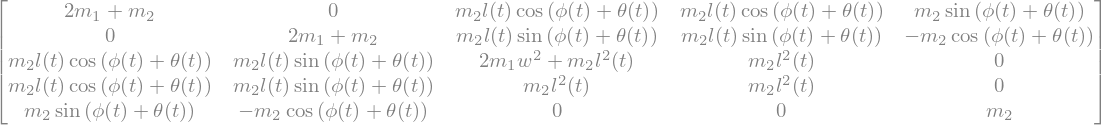

In [133]:
mass

### Part 3 Kinetic Energy

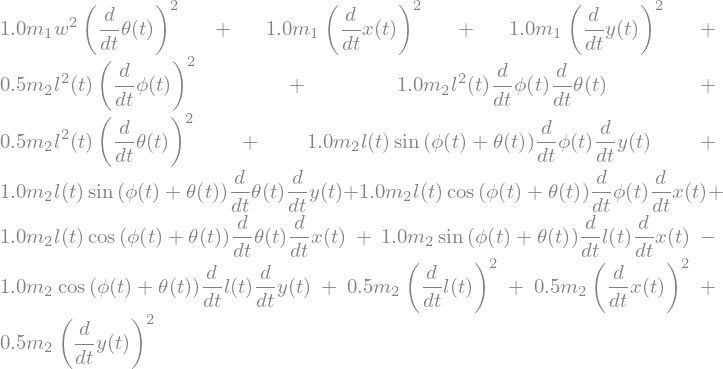

In [134]:
KE_tot

### Part 4 Potential Energy

In [135]:
V

### Part 5 Lagrangian Output

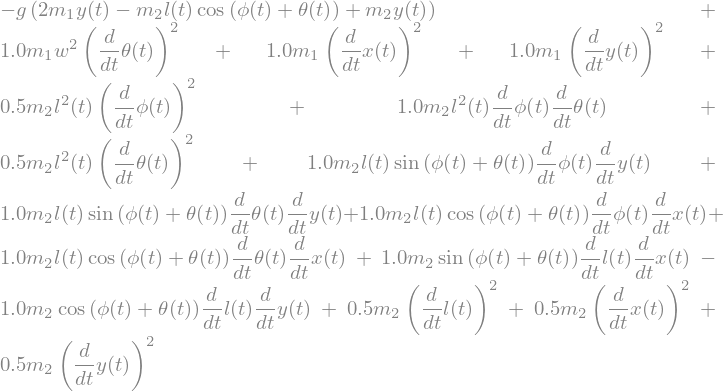

In [136]:
L

### Part 6 Mass Output

In [137]:
mass[1,2]

In [138]:
EOM = simplify(H - mass * Matrix(q_dtdt))

In [139]:
params_sym = [w, m1, m2, g]
 
M_lambda = lambdify([q, q_dt, params_sym], mass, modules='numpy')
EOM_lambda = lambdify([q, q_dt, params_sym], EOM, modules='numpy')
 
KE_lambda = lambdify([q,q_dt,params_sym],KE_tot)
PE_lambda = lambdify([q,q_dt,params_sym],V)

In [140]:
def dynamics(t, state, params,omega_val):
    x_v, y_v, theta_v, phi_v, l_v, xd_v, yd_v, thd_v, phd_v, ld_v = state

    q_n    = [x_v, y_v, theta_v, phi_v, l_v]
    q_dt_n = [xd_v, yd_v, thd_v, phd_v, ld_v]


    tau = np.array([[0],
                    [0],
                    [0],
                    [np.sin(omega_val * t)],
                    [np.cos(omega_val * t)]], dtype=float)
    M_num   = np.array(M_lambda(q_n, q_dt_n, params), dtype=float)
    EOM_num = np.array(EOM_lambda(q_n, q_dt_n, params), dtype=float)
    dydt = np.linalg.solve(M_num, tau - EOM_num)

    return [xd_v, yd_v, thd_v, phd_v, ld_v,
            dydt[0][0], dydt[1][0], dydt[2][0], dydt[3][0], dydt[4][0]]

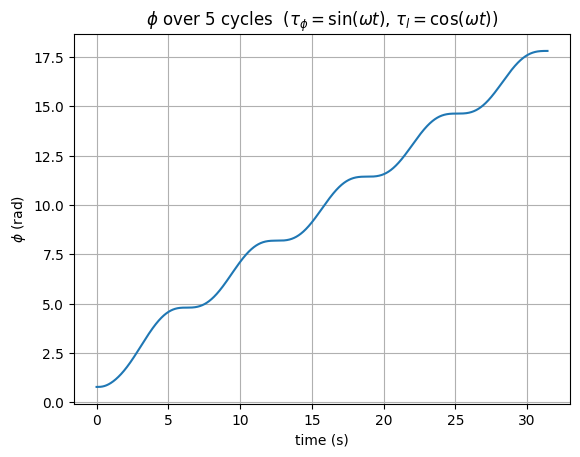

In [141]:
# Set up simulation
w_   = 1.0
m1_  = 1.0
m2_  = 1.0
g_   = 9.8
omega_val=1.0
params_ = [w_, m1_, m2_, g_]

# 5 cycles of oscillation (omega=1 rad/s → T = 2pi)
t_end = 5 * (2 * np.pi / omega_val)
dt = 0.001
time = np.linspace(0, t_end, int(t_end/dt))

# [x, y, theta, phi, l, x_dot, y_dot, theta_dot, phi_dot, l_dot]
init_state = [0, 1, 0, np.pi/4, 1, 0, 0, 0, 0, 0]

sol = solve_ivp(lambda t, y: dynamics(t, y, params_,omega_val),
                [0, t_end], init_state,
                t_eval=time,
                rtol=1e-8, atol=1e-8)

# Extract phi only
phi_sol = sol.y[3,:]

# Plot phi over 5 cycles
plt.figure()
plt.plot(sol.t, phi_sol)
plt.xlabel('time (s)')
plt.ylabel('$\\phi$ (rad)')
plt.title('$\\phi$ over 5 cycles  ($\\tau_\\phi = \\sin(\\omega t)$, $\\tau_l = \\cos(\\omega t)$)')
plt.grid(True)
plt.show()